In [14]:
import os
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [15]:

def load_root_file(file_path, branches=None, print_branches=False, print_keys=False):
    all_branches = {}
    with uproot.open(file_path) as file:
        tree = file["trackingNtuple/tree"]
        # Load all ROOT branches into array if not specified
        if branches is None:
            branches = tree.keys()
        # Option to print the branch names
        if print_branches:
            print("Branches:")
            for branch in branches:
                print(f"  {branch}")
        # Option to print the keys
        if print_keys:
            print("Keys:")
            for key in tree.keys():
                print(f"  {key}")
        # Each branch is added to the dictionary
        for branch in branches:
            try:
                all_branches[branch] = (tree[branch].array(library="np"))
            except uproot.KeyInFileError as e:
                print(f"KeyInFileError: {e}")
        # Number of events in file
        all_branches['event'] = tree.num_entries
    return all_branches


In [16]:

per_particle = [
    'sim_q',
    'sim_pt',
    'sim_pdgId',
    'sim_eta',
    'sim_phi',
    'sim_py', 'sim_px', 'sim_pz',
    'sim_nLay',
    #'simvtx_x', 'simvtx_y', 'simvtx_z',
    "sim_simHitIdx",
    "sim_pca_pt",
    "sim_pca_eta",
    "sim_pca_lambda",
    "sim_pca_cotTheta",
    "sim_pca_phi",
    "sim_pca_dxy",
    "sim_pca_dz",
]
# loop over these per hit
per_hit = [
    'simhit_x', 'simhit_y', 'simhit_z',
    'simhit_hitType',
    "simhit_isLower",
]
# concatenate the lists
branches_list = per_particle + per_hit 
print(f"branches_list: {branches_list}")

targets = [ # the 5 track parameters we want to predict
    "sim_pca_c",
    "sim_pca_eta",
    "sim_pca_phi",
    "sim_pca_dxy",
    "sim_pca_dz",
]


#file_path = "1000_no_dnn_for_phi.root"
#file_path="/data2/segmentlinking/trackingNtuple_10MuGun.root"
file_path = "/data2/segmentlinking/CMSSW_12_2_0_pre2/trackingNtuple_10mu_pt_0p5_50.root"
#file_path = "/data2/segmentlinking/CMSSW_12_2_0_pre2/trackingNtuple_10mu_pt_0p5_2.root"
branches = load_root_file(file_path, branches=branches_list, print_branches=True, print_keys=True)

branches_list: ['sim_q', 'sim_pt', 'sim_pdgId', 'sim_eta', 'sim_phi', 'sim_py', 'sim_px', 'sim_pz', 'sim_nLay', 'sim_simHitIdx', 'sim_pca_pt', 'sim_pca_eta', 'sim_pca_lambda', 'sim_pca_cotTheta', 'sim_pca_phi', 'sim_pca_dxy', 'sim_pca_dz', 'simhit_x', 'simhit_y', 'simhit_z', 'simhit_hitType', 'simhit_isLower']
Branches:
  sim_q
  sim_pt
  sim_pdgId
  sim_eta
  sim_phi
  sim_py
  sim_px
  sim_pz
  sim_nLay
  sim_simHitIdx
  sim_pca_pt
  sim_pca_eta
  sim_pca_lambda
  sim_pca_cotTheta
  sim_pca_phi
  sim_pca_dxy
  sim_pca_dz
  simhit_x
  simhit_y
  simhit_z
  simhit_hitType
  simhit_isLower
Keys:
  event
  lumi
  run
  trk_px
  trk_py
  trk_pz
  trk_pt
  trk_inner_px
  trk_inner_py
  trk_inner_pz
  trk_inner_pt
  trk_outer_px
  trk_outer_py
  trk_outer_pz
  trk_outer_pt
  trk_eta
  trk_lambda
  trk_cotTheta
  trk_phi
  trk_dxy
  trk_dz
  trk_dxyPV
  trk_dzPV
  trk_dxyClosestPV
  trk_dzClosestPV
  trk_ptErr
  trk_etaErr
  trk_lambdaErr
  trk_phiErr
  trk_dxyErr
  trk_dzErr
  trk_refpoint_

In [17]:
print(f"Number of events: {branches['event']}")
print(f"branches_list: {branches_list}")

Number of events: 9973
branches_list: ['sim_q', 'sim_pt', 'sim_pdgId', 'sim_eta', 'sim_phi', 'sim_py', 'sim_px', 'sim_pz', 'sim_nLay', 'sim_simHitIdx', 'sim_pca_pt', 'sim_pca_eta', 'sim_pca_lambda', 'sim_pca_cotTheta', 'sim_pca_phi', 'sim_pca_dxy', 'sim_pca_dz', 'simhit_x', 'simhit_y', 'simhit_z', 'simhit_hitType', 'simhit_isLower']


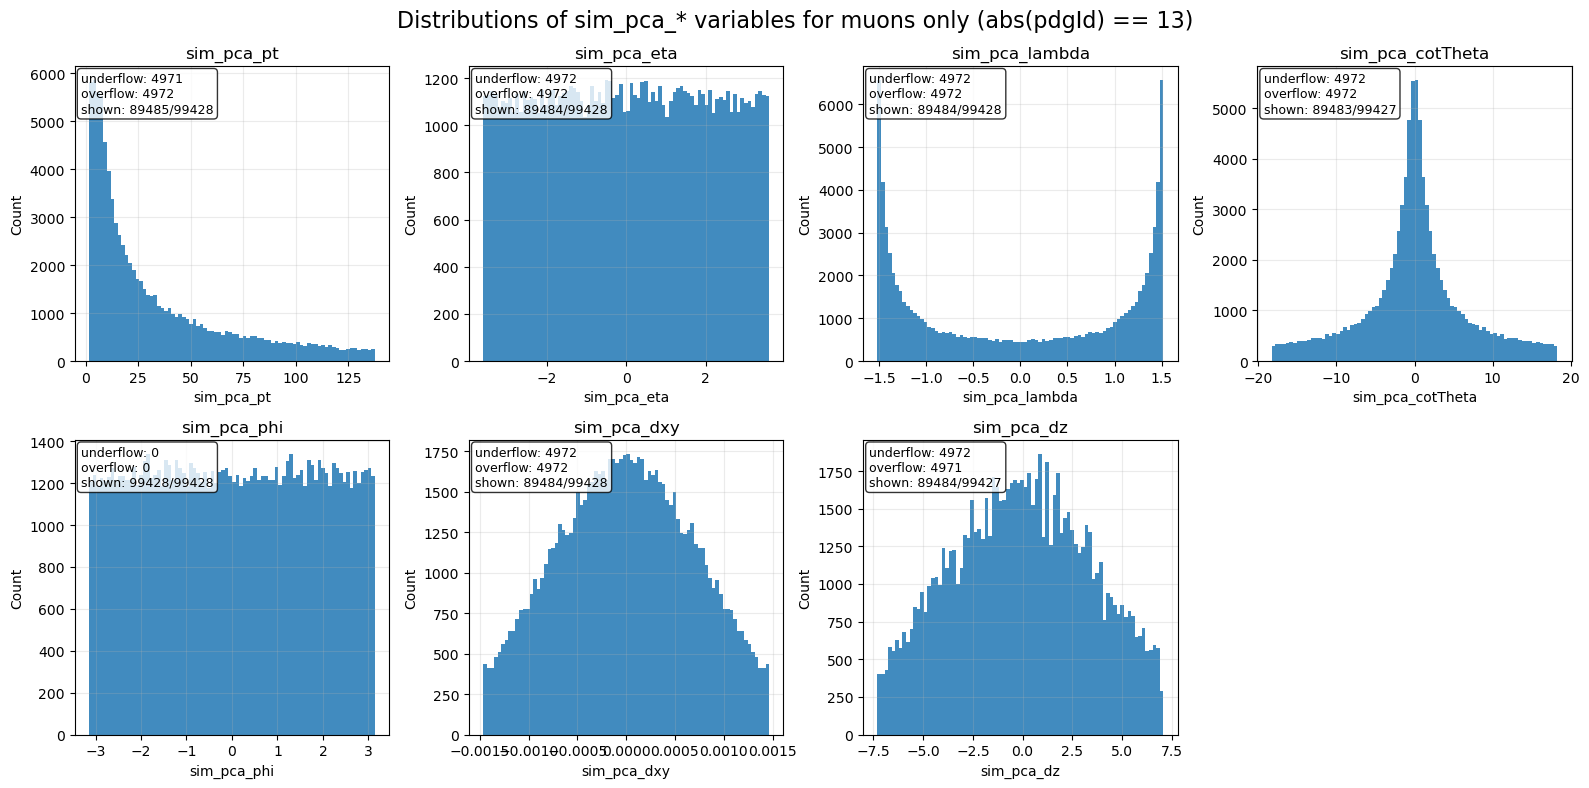

Lowest sim_pt value: 0.100 GeV


In [18]:
# Create histograms for all sim_pca_* variables from the raw data, now for muons only (abs(pdgId)=13). 
sim_pca_vars = [
    'sim_pca_pt',
    'sim_pca_eta',
    'sim_pca_lambda',
    'sim_pca_cotTheta',
    'sim_pca_phi',
    'sim_pca_dxy',
    'sim_pca_dz',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for k, var in enumerate(sim_pca_vars):
    ax = axes[k]
    
    # Flatten all events into a single array
    all_values = []
    for event in range(branches['event']):
        all_values.extend(branches[var][event].flatten())
    
    # only keep values for muons (abs(pdgId) == 13)
    all_values = np.array(all_values)
    all_pdgIds = np.concatenate([branches['sim_pdgId'][event].flatten() for event in range(branches['event'])])
    muon_mask = np.abs(all_pdgIds) == 13
    all_values = all_values[muon_mask]
    vals = np.asarray(all_values)
    vals = vals[np.isfinite(vals)]
    
    # Determine sensible bin boundaries
    if var == 'sim_pca_phi':
        xmin, xmax = -np.pi, np.pi
    else:
        percentile_low, percentile_high = np.percentile(vals, [5, 95])
        xmin, xmax = percentile_low, percentile_high
        if xmin == xmax:
            pad = 1e-6 if xmin == 0 else abs(xmin) * 1e-3
            xmin -= pad
            xmax += pad
    
    n_bins = 80
    in_range = vals[(vals >= xmin) & (vals <= xmax)]
    underflow = np.sum(vals < xmin)
    overflow = np.sum(vals > xmax)
    
    ax.hist(in_range, bins=n_bins, range=(xmin, xmax), alpha=0.85)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)
    
    ax.text(
        0.02, 0.98,
        f"underflow: {underflow}\noverflow: {overflow}\nshown: {len(in_range)}/{len(vals)}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

# Hide the last empty subplot
axes[-1].axis('off')
# title: muons only (abs(pdgId) == 13)
fig.suptitle("Distributions of sim_pca_* variables for muons only (abs(pdgId) == 13)", fontsize=16)

plt.tight_layout()
plt.show()

# print lowest pt value
all_sim_pt = np.concatenate([branches['sim_pt'][event].flatten() for event in range(branches['event'])])
print(f"Lowest sim_pt value: {all_sim_pt.min():.3f} GeV")

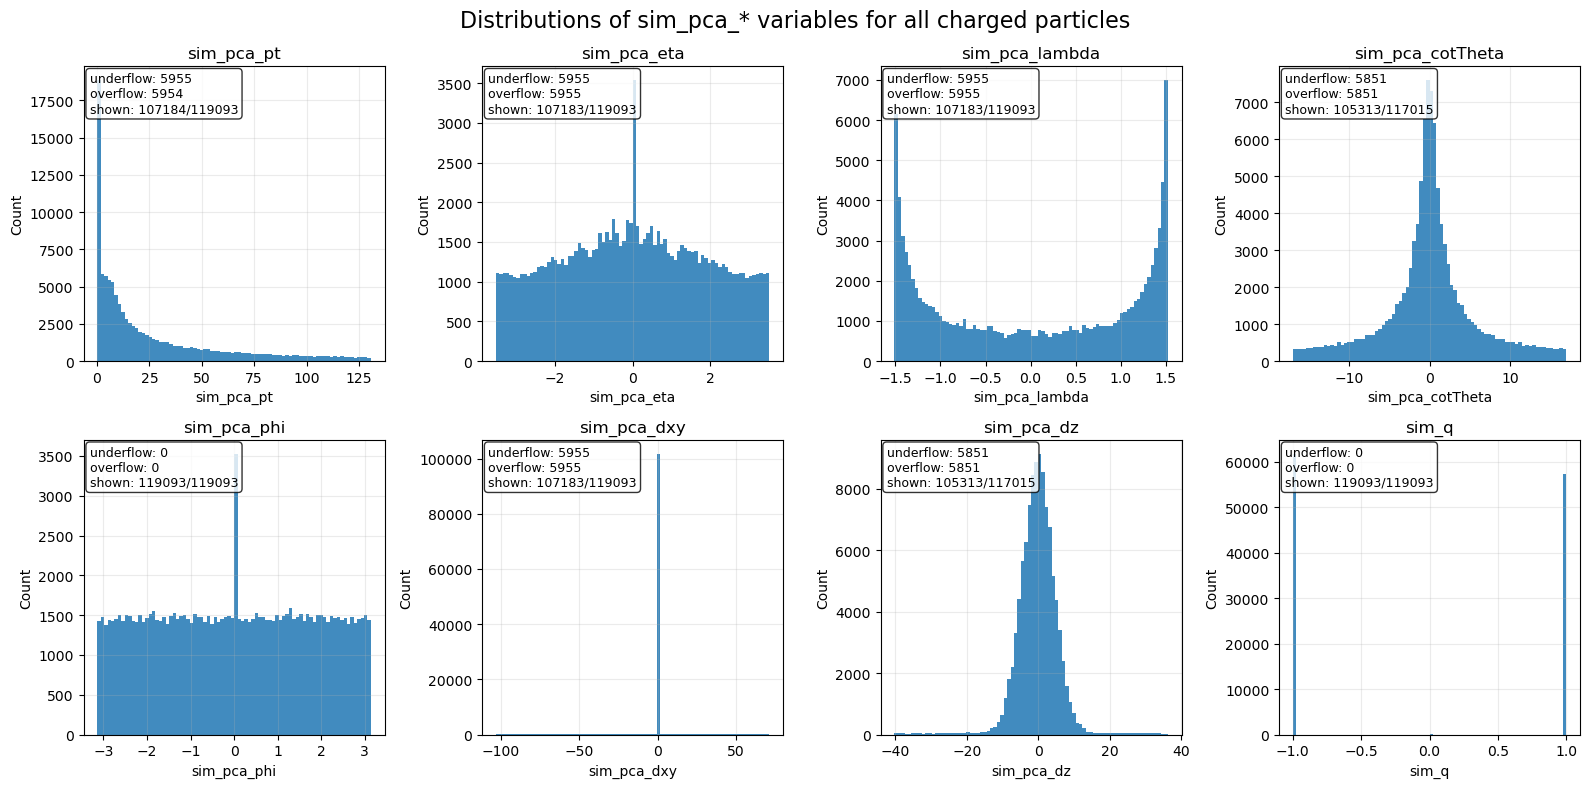

In [19]:
# Create histograms for all sim_pca_* variables from the raw data
sim_pca_vars = [
    'sim_pca_pt',
    'sim_pca_eta',
    'sim_pca_lambda',
    'sim_pca_cotTheta',
    'sim_pca_phi',
    'sim_pca_dxy',
    'sim_pca_dz',
    'sim_q'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for k, var in enumerate(sim_pca_vars):
    ax = axes[k]
    
    # Flatten all events into a single array
    all_values = []
    for event in range(branches['event']):
        all_values.extend(branches[var][event].flatten())
    
    vals = np.asarray(all_values)
    vals = vals[np.isfinite(vals)]
    
    # Determine sensible bin boundaries
    if var == 'sim_pca_phi':
        xmin, xmax = -np.pi, np.pi
    else:
        percentile_low, percentile_high = np.percentile(vals, [5, 95])
        xmin, xmax = percentile_low, percentile_high
        if xmin == xmax:
            pad = 1e-6 if xmin == 0 else abs(xmin) * 1e-3
            xmin -= pad
            xmax += pad
    
    n_bins = 80
    in_range = vals[(vals >= xmin) & (vals <= xmax)]
    underflow = np.sum(vals < xmin)
    overflow = np.sum(vals > xmax)
    
    ax.hist(in_range, bins=n_bins, range=(xmin, xmax), alpha=0.85)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)
    
    ax.text(
        0.02, 0.98,
        f"underflow: {underflow}\noverflow: {overflow}\nshown: {len(in_range)}/{len(vals)}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

# Hide the last empty subplot
#axes[-1].axis('off')

# title: all particles
fig.suptitle("Distributions of sim_pca_* variables for all charged particles", fontsize=16)

plt.tight_layout()
plt.show()

In [20]:
r_boundaries = [20, 30, 45, 60, 80, 100, 120]

def barrel_layer(x:float, y:float) -> int:
    """Determine the barrel layer based on the radius."""
    r = np.sqrt(x**2 + y**2)
    if r < r_boundaries[1]:
        return 0
    elif r < r_boundaries[2]:
        return 1
    elif r < r_boundaries[3]:
        return 2
    elif r < r_boundaries[4]:
        return 3
    elif r < r_boundaries[5]:
        return 4
    elif r < r_boundaries[6]:
        return 5
    else:
        return -1  # dunno what's going on here


In [21]:
ii = 0
for event in range(branches['event']):
    print(f"Event {event} i={ii}:")
    # number of particles in this event
    n_particles = len(branches['sim_pdgId'][event])
    print(f"  Number of particles: {n_particles}")
    # loop over particles
    for i in range(n_particles):
        print(f"  Particle {i}:")
        #print(f"debug: event {event}, particle {i}")
        for branch in per_particle:
            #print(f"debug: branch {branch}, event {event}, particle {i}")
            value = branches[branch][event][i]
            print(f"    {branch}: {value}")
        # loop over hits for this particle
        hit_indices = branches["sim_simHitIdx"][event][i]
        n_hits = len(hit_indices)
        print(f"    Number of hits: {n_hits}")
        for j in range(n_hits):
            hit_index = hit_indices[j]
            print(f"    Hit {j} (index {hit_index}):")
            x_pos = branches['simhit_x'][event][hit_index]
            y_pos = branches['simhit_y'][event][hit_index]
            r = np.sqrt(x_pos**2 + y_pos**2)
            layer = barrel_layer(x_pos, y_pos)
            print(f"      x: {x_pos}, y: {y_pos}")
            print(f"      r: {r}")
            print(f"      layer: {layer}")
            z_pos = branches['simhit_z'][event][hit_index]
            print(f"      z: {z_pos}")
            hit_type = branches['simhit_hitType'][event][hit_index][0]
            print(f"      hitType: {hit_type}")
    # quit after 2nd event for testing
    if ii > 2:
        break
    ii += 1

Event 0 i=0:
  Number of particles: 10
  Particle 0:
    sim_q: 1
    sim_pt: 39.10930633544922
    sim_pdgId: -13
    sim_eta: -1.9570250511169434
    sim_phi: -0.6529746055603027
    sim_py: -23.760927200317383
    sim_px: 31.063743591308594
    sim_pz: -135.6498565673828
    sim_nLay: 12
    sim_simHitIdx: [161, 162, 160, 159, 158, 157, 156, 163, ..., 149, 142, 143, 144, 145, 146, 147, 148]
    sim_pca_pt: 39.10930633544922
    sim_pca_eta: -1.9570250511169434
    sim_pca_lambda: -1.2900978326797485
    sim_pca_cotTheta: -3.468480348587036
    sim_pca_phi: -0.6529742479324341
    sim_pca_dxy: 0.0007404406205751002
    sim_pca_dz: 0.5361964702606201
    Number of hits: 23
    Hit 0 (index 161):
      x: 2.225818395614624, y: -1.703057050704956
      r: 2.8026185035705566
      layer: 0
      z: -9.164905548095703
      hitType: 0
    Hit 1 (index 162):
      x: 4.6848015785217285, y: -3.5886778831481934
      r: 5.901353359222412
      layer: 0
      z: -19.912389755249023
      hitT

Event 0:
Event 100:
Event 200:
Event 300:
Event 400:
Event 500:
Event 600:
Event 700:
Event 800:
Event 900:
Event 1000:
Event 1100:
Event 1200:
Event 1300:
Event 1400:
Event 1500:
Event 1600:
Event 1700:
Event 1800:
Event 1900:
Event 2000:
Event 2100:
Event 2200:
Event 2300:
Event 2400:
Event 2500:
Event 2600:
Event 2700:
Event 2800:
Event 2900:
Event 3000:
Event 3100:
Event 3200:
Event 3300:
Event 3400:
Event 3500:
Event 3600:
Event 3700:
Event 3800:
Event 3900:
Event 4000:
Event 4100:
Event 4200:
Event 4300:
Event 4400:
Event 4500:
Event 4600:
Event 4700:
Event 4800:
Event 4900:
Event 5000:
Event 5100:
Event 5200:
Event 5300:
Event 5400:
Event 5500:
Event 5600:
Event 5700:
Event 5800:
Event 5900:
Event 6000:
Event 6100:
Event 6200:
Event 6300:
Event 6400:
Event 6500:
Event 6600:
Event 6700:
Event 6800:
Event 6900:
Event 7000:
Event 7100:
Event 7200:
Event 7300:
Event 7400:
Event 7500:
Event 7600:
Event 7700:
Event 7800:
Event 7900:
Event 8000:
Event 8100:
Event 8200:
Event 8300:
Even

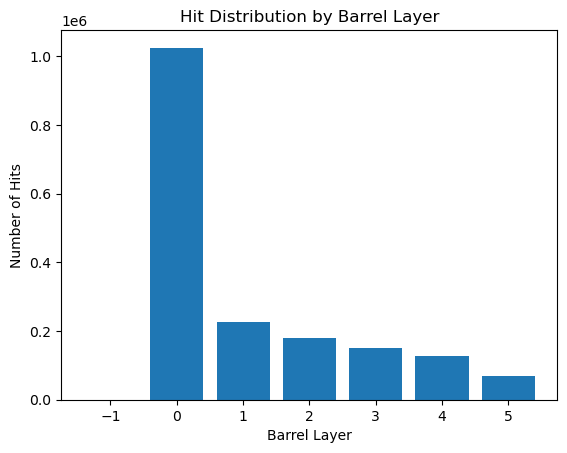

Layer counts: {0: 1024562, 1: 225578, 2: 178895, 3: 149561, 4: 125825, 5: 67715, -1: 0}


In [22]:
layer_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, -1: 0}
for event in range(branches['event']):
    if event % 100 == 0:
        print(f"Event {event}:")
    n_particles = len(branches['sim_pdgId'][event])
    for i in range(n_particles):
        hit_indices = branches["sim_simHitIdx"][event][i]
        n_hits = len(hit_indices)
        for j in range(n_hits):
            hit_index = hit_indices[j]
            x_pos = branches['simhit_x'][event][hit_index]
            y_pos = branches['simhit_y'][event][hit_index]
            r = np.sqrt(x_pos**2 + y_pos**2)
            layer = barrel_layer(x_pos, y_pos)
            layer_counts[layer] += 1

# make a histogram of the layer counts
plt.bar(layer_counts.keys(), layer_counts.values())
plt.xlabel("Barrel Layer")
plt.ylabel("Number of Hits")
plt.title("Hit Distribution by Barrel Layer")
plt.show()
print(f"Layer counts: {layer_counts}")

Select sim particles in the central region |eta|<0 and within a central |z0| and |d0|, for muons only with pdgId = \pm 13.

In [ ]:
etacut = 0.9
ptcut = 1.9
hittype = 4 # this appears to be ot hits (see below)
muon_pdgId = 13
max_OTHits = 0


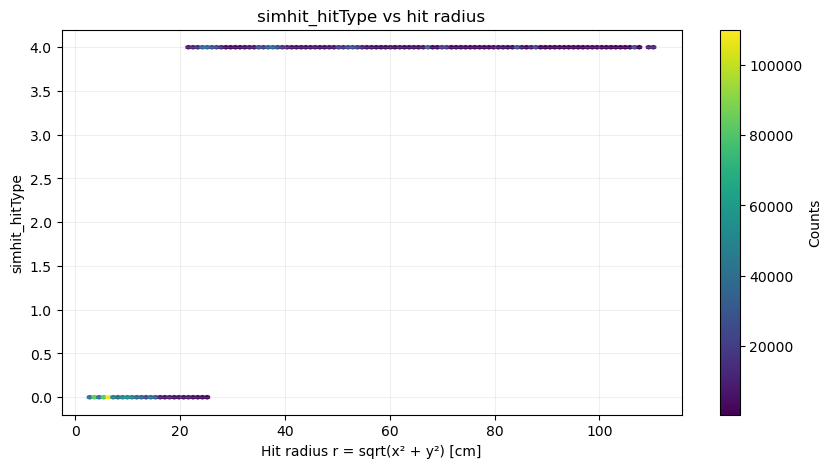

In [33]:
# Plot simhit_hitType vs hit radius for all hits

r_list = []
hittype_list = []

for event in range(branches["event"]):
    x_evt = branches["simhit_x"][event]
    y_evt = branches["simhit_y"][event]
    ht_evt = branches["simhit_hitType"][event]

    n_hits_evt = min(len(x_evt), len(y_evt), len(ht_evt))
    for h in range(n_hits_evt):
        vv = ht_evt[h]
        try:
            hit_type = vv[0] if len(vv) > 0 else -1
        except TypeError:
            hit_type = vv

        r_list.append(np.sqrt(x_evt[h] ** 2 + y_evt[h] ** 2))
        hittype_list.append(hit_type)

r_vals = np.asarray(r_list, dtype=np.float32)
hittype_vals = np.asarray(hittype_list, dtype=np.int32)

valid = np.isfinite(r_vals) & (hittype_vals >= 0)
r_vals = r_vals[valid]
hittype_vals = hittype_vals[valid]

plt.figure(figsize=(10, 5))
hb = plt.hexbin(r_vals, hittype_vals, gridsize=120, mincnt=1, cmap="viridis")
plt.colorbar(hb, label="Counts")
plt.xlabel("Hit radius r = sqrt(x² + y²) [cm]")
plt.ylabel("simhit_hitType")
plt.title("simhit_hitType vs hit radius")
plt.grid(alpha=0.2)
plt.show()

In [24]:
# Store one OT hit per barrel layer (0..5) for each selected particle
n_layers = 6
sentinel = -999.0

onehit_x_list, onehit_y_list, onehit_z_list = [], [], []
filled_layers_list = []
hitmask_list = []
sel_event_idx, sel_particle_idx = [], []

# Dynamic lists - one entry per selected particle
pca_c_list = []
pca_eta_list = []
pca_phi_list = []
pca_dxy_list = []
pca_dz_list = []
pca_pt_list = [] # just for plotting, not used for training

for event in range(branches["event"]):
    if event % 500 == 0:
        print(f"Event {event}:")
    n_particles = len(branches["sim_pdgId"][event])

    for i in range(n_particles):
        sim_eta = branches["sim_eta"][event][i]
        sim_pt = branches["sim_pt"][event][i]
        sim_pdgId = branches["sim_pdgId"][event][i]

        # same particle selection as later cells
        if abs(sim_eta) > etacut or sim_pt < ptcut or abs(sim_pdgId) != muon_pdgId:
            continue
        sim_q = branches["sim_q"][event][i]
        pca_c_list.append(sim_q / branches['sim_pca_pt'][event][i])
        pca_eta_list.append(branches['sim_pca_eta'][event][i])
        pca_phi_list.append(branches['sim_pca_phi'][event][i])
        pca_dxy_list.append(branches['sim_pca_dxy'][event][i])
        pca_dz_list.append(branches['sim_pca_dz'][event][i])

        # store pt just for plotting
        pca_pt_list.append(sim_pt)
        

        row_x = np.full(n_layers, sentinel, dtype=np.float32)
        row_y = np.full(n_layers, sentinel, dtype=np.float32)
        row_z = np.full(n_layers, sentinel, dtype=np.float32)
        hit_mask = np.full(n_layers, 0, dtype=np.int32)
        seen = np.zeros(n_layers, dtype=bool)

        hit_indices = branches["sim_simHitIdx"][event][i]
        for j in range(len(hit_indices)):
            hit_index = hit_indices[j]

            vv = branches["simhit_hitType"][event][hit_index]
            hit_type = vv[0] if len(vv) > 0 else -1
            if hit_type != hittype:
                continue
            if branches["simhit_isLower"][event][hit_index] != 1:
                continue

            x = branches["simhit_x"][event][hit_index]
            y = branches["simhit_y"][event][hit_index]
            z = branches["simhit_z"][event][hit_index]
            layer = barrel_layer(x, y)
            if layer == 3 and x**2 + y**2 < 41**2:
                print(f"Debug: Event {event}, Particle {i}, Hit {j}:")
                print(f"  x: {x}, y: {y}, z: {z}, layer: {layer}, hitType: {hit_type}")

            if 0 <= layer < n_layers and not seen[layer]:
                row_x[layer] = x
                row_y[layer] = y
                row_z[layer] = z
                seen[layer] = True
                hit_mask[layer] = 1

            if np.all(seen):
                break
        # print out if all of the six layers have no hits
        if not np.any(seen):
            print(f"Weird: Event {event}, Particle {i} has no hits in any of the 6 layers.")
            print(f"  sim_eta: {sim_eta}, sim_pt: {sim_pt}, sim_pdgId: {sim_pdgId}")
            # can't skip because we already added it to the PCA lists

        onehit_x_list.append(row_x)
        onehit_y_list.append(row_y)
        onehit_z_list.append(row_z)
        filled_layers_list.append(np.sum(seen))
        hitmask_list.append(hit_mask)
        sel_event_idx.append(event)
        sel_particle_idx.append(i)

onehit_x = np.array(onehit_x_list)
onehit_y = np.array(onehit_y_list)
onehit_z = np.array(onehit_z_list)
filled_layers = np.array(filled_layers_list)
hitmask = np.array(hitmask_list)
sel_event_idx = np.array(sel_event_idx)
sel_particle_idx = np.array(sel_particle_idx)


pca_c = np.array(pca_c_list)
pca_eta = np.array(pca_eta_list)
pca_phi = np.array(pca_phi_list)
pca_dxy = np.array(pca_dxy_list)
pca_dz = np.array(pca_dz_list)

pca_pt = np.array(pca_pt_list)


print("Shapes:")
print("  onehit_x:", onehit_x.shape)
print("  onehit_y:", onehit_y.shape)
print("  onehit_z:", onehit_z.shape)
print("Selected particles:", len(filled_layers))
print("Average filled layers per particle:", filled_layers.mean() if len(filled_layers) else 0.0)

# copy to other names
othit_x = onehit_x
othit_y = onehit_y
othit_z = onehit_z
othit_mask = hitmask

Event 0:
Event 500:
Event 1000:
Event 1500:
Event 2000:
Weird: Event 2380, Particle 24 has no hits in any of the 6 layers.
  sim_eta: 0.6135722398757935, sim_pt: 4.618149757385254, sim_pdgId: 13
Event 2500:
Event 3000:
Event 3500:
Event 4000:
Event 4500:
Event 5000:
Event 5500:
Event 6000:
Event 6500:
Event 7000:
Event 7500:
Event 8000:
Event 8500:
Event 9000:
Event 9500:
Shapes:
  onehit_x: (22513, 6)
  onehit_y: (22513, 6)
  onehit_z: (22513, 6)
Selected particles: 22513
Average filled layers per particle: 5.996535335139697


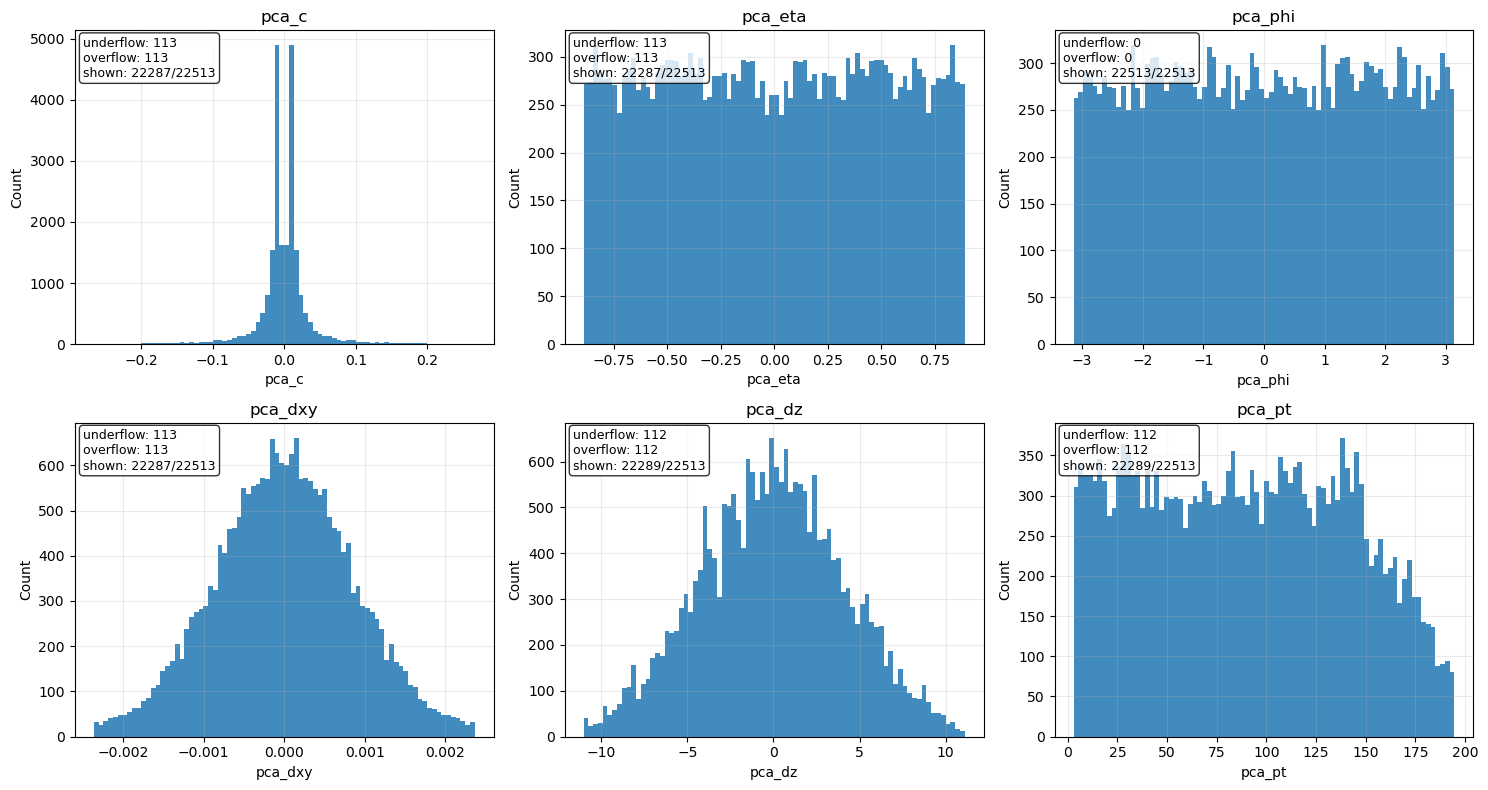

In [25]:
# Histograms for PCA targets with robust binning + underflow/overflow annotations

pca_data = {
    "pca_c": pca_c,
    "pca_eta": pca_eta,
    "pca_phi": pca_phi,
    "pca_dxy": pca_dxy,
    "pca_dz": pca_dz,
    "pca_pt": pca_pt,
}

def robust_range(arr, qlow=0.5, qhigh=99.5):
    a = np.asarray(arr)
    a = a[np.isfinite(a)]
    lo, hi = np.percentile(a, [qlow, qhigh])
    if lo == hi:
        pad = 1e-6 if lo == 0 else abs(lo) * 1e-3
        lo -= pad
        hi += pad
    return lo, hi

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for k, (name, arr) in enumerate(pca_data.items()):
    ax = axes[k]
    vals = np.asarray(arr)
    vals = vals[np.isfinite(vals)]

    # Use full physical range for phi, robust percentile range for others
    if name == "pca_phi":
        xmin, xmax = -np.pi, np.pi
    else:
        xmin, xmax = robust_range(vals, qlow=0.5, qhigh=99.5)

    n_bins = 80
    in_range = vals[(vals >= xmin) & (vals <= xmax)]
    underflow = np.sum(vals < xmin)
    overflow = np.sum(vals > xmax)

    ax.hist(in_range, bins=n_bins, range=(xmin, xmax), alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)

    ax.text(
        0.02, 0.98,
        f"underflow: {underflow}\noverflow: {overflow}\nshown: {len(in_range)}/{len(vals)}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )


plt.tight_layout()
plt.show()

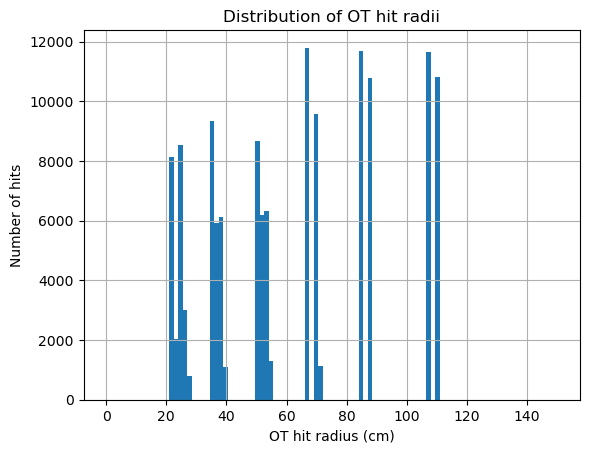

In [26]:
othits_r = np.sqrt(othit_x**2 + othit_y**2)
plt.hist(othits_r.flatten(), bins=100, range=(0, 150))
plt.xlabel("OT hit radius (cm)")
plt.ylabel("Number of hits")
plt.title("Distribution of OT hit radii")
plt.grid()

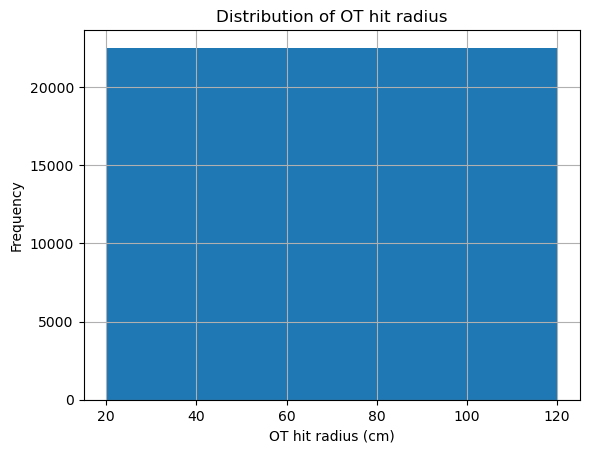

In [27]:
# determine boundries to cluster the hits in 6 groups in radius
plt.hist(othits_r.flatten(), bins=r_boundaries)
plt.xlabel("OT hit radius (cm)")
plt.ylabel("Frequency")
plt.title("Distribution of OT hit radius")
plt.grid()

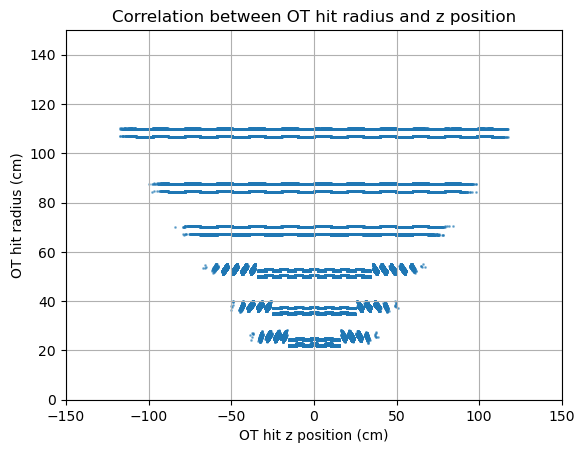

In [28]:
plt.scatter( othit_z.flatten(), othits_r.flatten(), s=1, alpha=0.5)
plt.xlim(-150, 150)
plt.ylim(0, 150)
plt.xlabel("OT hit z position (cm)")
plt.ylabel("OT hit radius (cm)")
plt.title("Correlation between OT hit radius and z position")
plt.grid()

In [29]:
onehit_x = np.array(onehit_x_list)
onehit_y = np.array(onehit_y_list)
onehit_z = np.array(onehit_z_list)
filled_layers = np.array(filled_layers_list)
hitmask = np.array(hitmask_list)


n_export_hits = 6
if onehit_x.shape[1] < n_export_hits:
    raise ValueError(
        f"Expected at least {n_export_hits} hits per particle, found {onehit_x.shape[1]}"
    )
if hitmask.shape[1] < n_export_hits:
    raise ValueError(
        f"Expected at least {n_export_hits} hit mask values per particle, found {hitmask.shape[1]}"
    )

hit_columns = {}
for hit_idx in range(n_export_hits):
    hit_columns[f"hit_{hit_idx + 1}_x"] = onehit_x[:, hit_idx]
    hit_columns[f"hit_{hit_idx + 1}_y"] = onehit_y[:, hit_idx]
    hit_columns[f"hit_{hit_idx + 1}_z"] = onehit_z[:, hit_idx]
    hit_columns[f"hit_{hit_idx + 1}_r"] = np.sqrt(onehit_x[:, hit_idx]**2 + onehit_y[:, hit_idx]**2)
    hit_columns[f"hit_{hit_idx + 1}_mask"] = hitmask[:, hit_idx]

df = pd.DataFrame(
    {
        "pca_c": pca_c,
        "pca_eta": pca_eta,
        "pca_phi": pca_phi,
        "pca_dxy": pca_dxy,
        "pca_dz": pca_dz,
        **hit_columns,
    }
)

df.to_csv("selected_particles_0.csv", index=False)
print(f"Exported {len(df)} particles to selected_particles_0.csv")
df.head()

Exported 22513 particles to selected_particles_0.csv


,pca_c,pca_eta,pca_phi,pca_dxy,pca_dz,hit_1_x,hit_1_y,hit_1_z,hit_1_r,hit_1_mask,...,hit_5_x,hit_5_y,hit_5_z,hit_5_r,hit_5_mask,hit_6_x,hit_6_y,hit_6_z,hit_6_r,hit_6_mask
0,0.008713,0.160019,0.119688,0.001111,-0.484953,24.132765,2.874294,3.440747,24.303329,1,...,86.868530,10.067498,13.591102,87.449966,1,109.083817,12.518445,17.183611,109.799774,1
1,-0.008713,-0.160019,-3.021905,-0.001111,-0.484953,-21.757307,-2.640304,-3.988145,21.916925,1,...,-87.056763,-10.859695,-14.571457,87.731483,1,-106.106506,-13.339738,-17.661728,106.941757,1
2,0.067234,-0.113927,-0.065992,-0.000670,-3.437733,21.934038,-1.638019,-5.925012,21.995115,1,...,87.281082,-8.725406,-13.404287,87.716133,1,109.408409,-11.870730,-15.946019,110.050507,1
3,-0.067234,0.113927,3.075601,0.000670,-3.437733,-24.848265,1.405060,-0.582126,24.887959,1,...,-84.555000,2.845906,6.219305,84.602875,1,-106.855003,2.676765,8.765812,106.888527,1
4,0.082615,-0.838687,0.332262,0.000270,9.648345,21.192055,7.064784,-11.333022,22.338629,1,...,84.056961,25.150980,-72.803345,87.739067,1,105.779625,30.438492,-93.807823,110.071938,1


In [30]:
# now store the same data again, but with a tighter pt cut of 5 GeV.
pt_cut = 5.0
df_pt5 = df[pca_pt >= pt_cut].copy()
print(f"Number of particles with pt >= {pt_cut} GeV: {len(df_pt5)}")
df_pt5.to_csv("selected_particles_pt5.csv", index=False)
print(f"Exported {len(df_pt5)} particles to selected_particles_pt5.csv")
df_pt5.head()

Number of particles with pt >= 5.0 GeV: 22134
Exported 22134 particles to selected_particles_pt5.csv


,pca_c,pca_eta,pca_phi,pca_dxy,pca_dz,hit_1_x,hit_1_y,hit_1_z,hit_1_r,hit_1_mask,...,hit_5_x,hit_5_y,hit_5_z,hit_5_r,hit_5_mask,hit_6_x,hit_6_y,hit_6_z,hit_6_r,hit_6_mask
0,0.008713,0.160019,0.119688,0.001111,-0.484953,24.132765,2.874294,3.440747,24.303329,1,...,86.868530,10.067498,13.591102,87.449966,1,109.083817,12.518445,17.183611,109.799774,1
1,-0.008713,-0.160019,-3.021905,-0.001111,-0.484953,-21.757307,-2.640304,-3.988145,21.916925,1,...,-87.056763,-10.859695,-14.571457,87.731483,1,-106.106506,-13.339738,-17.661728,106.941757,1
2,0.067234,-0.113927,-0.065992,-0.000670,-3.437733,21.934038,-1.638019,-5.925012,21.995115,1,...,87.281082,-8.725406,-13.404287,87.716133,1,109.408409,-11.870730,-15.946019,110.050507,1
3,-0.067234,0.113927,3.075601,0.000670,-3.437733,-24.848265,1.405060,-0.582126,24.887959,1,...,-84.555000,2.845906,6.219305,84.602875,1,-106.855003,2.676765,8.765812,106.888527,1
4,0.082615,-0.838687,0.332262,0.000270,9.648345,21.192055,7.064784,-11.333022,22.338629,1,...,84.056961,25.150980,-72.803345,87.739067,1,105.779625,30.438492,-93.807823,110.071938,1


In [31]:
# third file with softer tracks
pt_cut = 20.0
df_ptbelow10 = df[pca_pt < pt_cut].copy()
print(f"Number of particles with pt < {pt_cut} GeV: {len(df_ptbelow10)}")
df_ptbelow10.to_csv("selected_particles_ptbelow10.csv", index=False)
print(f"Exported {len(df_ptbelow10)} particles to selected_particles_ptbelow10.csv")
df_ptbelow10.head()

Number of particles with pt < 20.0 GeV: 2433
Exported 2433 particles to selected_particles_ptbelow10.csv


,pca_c,pca_eta,pca_phi,pca_dxy,pca_dz,hit_1_x,hit_1_y,hit_1_z,hit_1_r,hit_1_mask,...,hit_5_x,hit_5_y,hit_5_z,hit_5_r,hit_5_mask,hit_6_x,hit_6_y,hit_6_z,hit_6_r,hit_6_mask
2,0.067234,-0.113927,-0.065992,-0.000670,-3.437733,21.934038,-1.638019,-5.925012,21.995115,1,...,87.281082,-8.725406,-13.404287,87.716133,1,109.408409,-11.870730,-15.946019,110.050507,1
3,-0.067234,0.113927,3.075601,0.000670,-3.437733,-24.848265,1.405060,-0.582126,24.887959,1,...,-84.555000,2.845906,6.219305,84.602875,1,-106.855003,2.676765,8.765812,106.888527,1
4,0.082615,-0.838687,0.332262,0.000270,9.648345,21.192055,7.064784,-11.333022,22.338629,1,...,84.056961,25.150980,-72.803345,87.739067,1,105.779625,30.438492,-93.807823,110.071938,1
5,-0.082615,0.838687,-2.809330,-0.000270,9.648345,-22.735756,-8.142274,32.381901,24.149767,1,...,-78.585495,-30.716625,89.051956,84.375298,1,-101.771027,-41.189945,112.982117,109.790497,1
66,0.212619,-0.374583,1.428447,0.001309,-1.879367,3.839353,22.370735,-10.547268,22.697807,1,...,21.736494,85.054375,-35.357635,87.787933,1,28.805332,102.654922,-42.562363,106.619797,1


In [32]:
# find the minima for each hit radius column of the radius and compare to the expected one based on the barrel layer boundaries
for hit_idx in range(n_export_hits):
    r_col = f"hit_{hit_idx + 1}_r"
    mask_col = f"hit_{hit_idx + 1}_mask"
    valid_radii = df[r_col][df[mask_col] == 1]
    if len(valid_radii) > 0:
        min_radius = valid_radii.min()
        print(f"Minimum radius for hit {hit_idx + 1}: {min_radius:.2f} cm (expected ~{r_boundaries[hit_idx]} cm)")
    else:
        print(f"No valid hits found for hit {hit_idx + 1}")

Minimum radius for hit 1: 21.89 cm (expected ~20 cm)
Minimum radius for hit 2: 34.75 cm (expected ~30 cm)
Minimum radius for hit 3: 49.93 cm (expected ~45 cm)
Minimum radius for hit 4: 66.98 cm (expected ~60 cm)
Minimum radius for hit 5: 84.28 cm (expected ~80 cm)
Minimum radius for hit 6: 106.58 cm (expected ~100 cm)
